In [1]:
%%capture
!pip install --user "ibm-watsonx-ai==0.2.6"
!pip install --user "langchain==0.1.16" 
!pip install --user "langchain-ibm==0.1.4"
!pip install --user "langchain-experimental==0.0.57"
!pip install --user "matplotlib==3.8.4"
!pip install --user "seaborn==0.13.2"

In [1]:
# You can use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

from ibm_watsonx_ai.foundation_models import Model
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
from ibm_watson_machine_learning.foundation_models.extensions.langchain import WatsonxLLM

from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZNoKMJ9rssJn-QbJ49kOzA/student-mat.csv"
)

In [3]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [5]:
# Create a dictionary to store credential information
credentials = {
    "url"    : "https://us-south.ml.cloud.ibm.com"
}

# Indicate the model you would like to initialize. In this case, Llama 4 Maverick.
model_id    ='meta-llama/llama-4-maverick-17b-128e-instruct-fp8'

# Initialize some watsonx.ai model parameters
params = {
        GenParams.MAX_NEW_TOKENS: 256, # The maximum number of tokens that the model can generate in a single run.
        GenParams.TEMPERATURE: 0,   # A parameter that controls the randomness of the token generation. A lower value makes the generation more deterministic, while a higher value introduces more randomness.
    }
project_id  = "skills-network" # <--- NOTE: specify "skills-network" as your project_id
space_id    = None
verify      = False

# Launch a watsonx.ai model
model = Model(
    model_id=model_id, 
    credentials=credentials, 
    params=params, 
    project_id=project_id, 
    space_id=space_id, 
    verify=verify
)

# Integrate the watsonx.ai model with the langchain framework
llm = WatsonxLLM(model = model)

agent = create_pandas_dataframe_agent(
    llm,
    df,
    verbose=False,
    return_intermediate_steps=True,  # set return_intermediate_steps=True so that model could return code that it comes up with to generate the chart
    handle_parsing_errors=True,
    prefix="You are a pandas agent. Always respond using Action/Action Input/Final Answer format. Never output raw data directly."
)

In [6]:
response = agent.invoke("how many rows of data are in this file?")

In [7]:
response['output']

'395 rows.'

In [8]:
len(df)

395

In [9]:
response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n')

'df.shape'

In [10]:
response = agent.invoke("Give me all the data where student's age is over 18 years old.")

In [11]:
print(response)

{'input': "Give me all the data where student's age is over 18 years old.", 'output': "The data where the student's age is over 18 years old is stored in the filtered DataFrame. The result contains 30 rows.", 'intermediate_steps': [(AgentAction(tool='python_repl_ast', tool_input="df[df['age'] > 18]", log="<|python_start|><|header_start|>assistant<|header_end|>\n\nThought: To get the data where the student's age is over 18 years old, I need to filter the DataFrame `df` based on the condition that `age` is greater than 18.\n\nAction: python_repl_ast\nAction Input: df[df['age'] > 18]"),     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
127     GP   F   19       U     GT3       T     0     1   at_home     other   
153     GP   M   19       U     GT3       T     3     2  services   at_home   
210     GP   F   19       U     GT3       T     3     3     other     other   
247     GP   M   22       U     GT3       T     3     1  services  services   
257     GP   M

In [12]:
response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n')

"df[df['age'] > 18]"

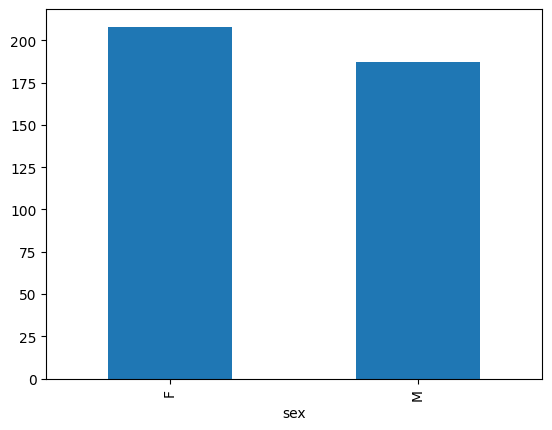

In [13]:
response = agent.invoke("Generate a bar chart to plot the gender count.")

In [14]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

import matplotlib.pyplot as plt
plt.show()

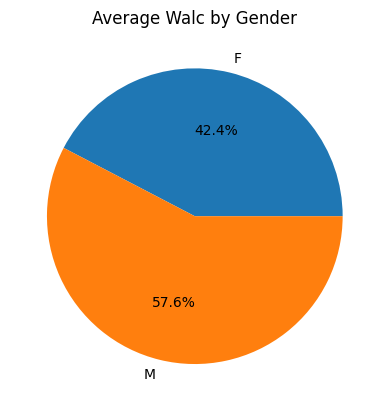

In [15]:
response = agent.invoke("Generate a pie chart to display average value of Walc for each Gender.")

In [16]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

import matplotlib.pyplot as plt
df.groupby('sex')['Walc'].mean().plot(kind='pie', autopct='%1.1f%%')
plt.title('Average Walc by Gender')
plt.show()

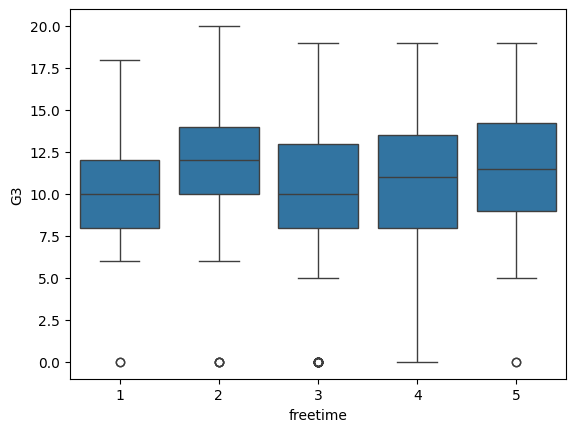

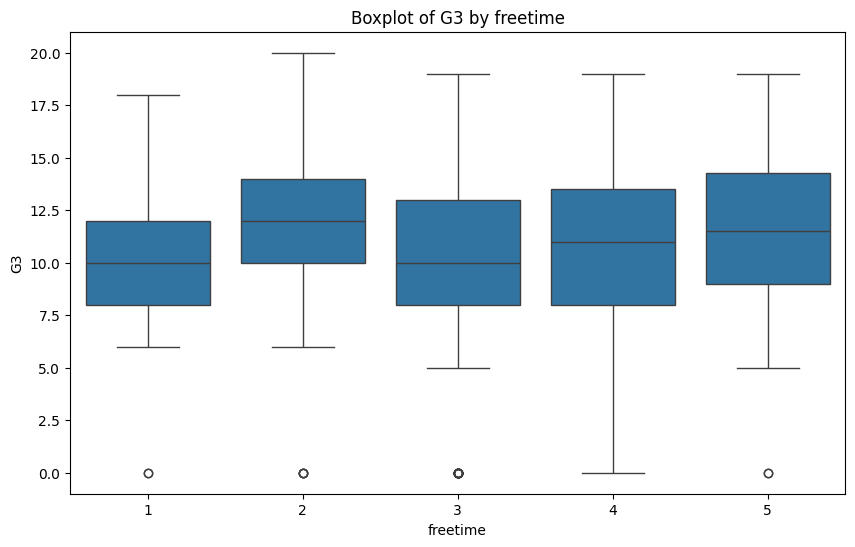

In [17]:
response = agent.invoke("Create box plots to analyze the relationship between 'freetime' (amount of free time) and 'G3' (final grade) across different levels of free time.")

In [18]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

plt.figure(figsize=(10,6))
sns.boxplot(x='freetime', y='G3', data=df)
plt.title('Boxplot of G3 by freetime')
plt.show()

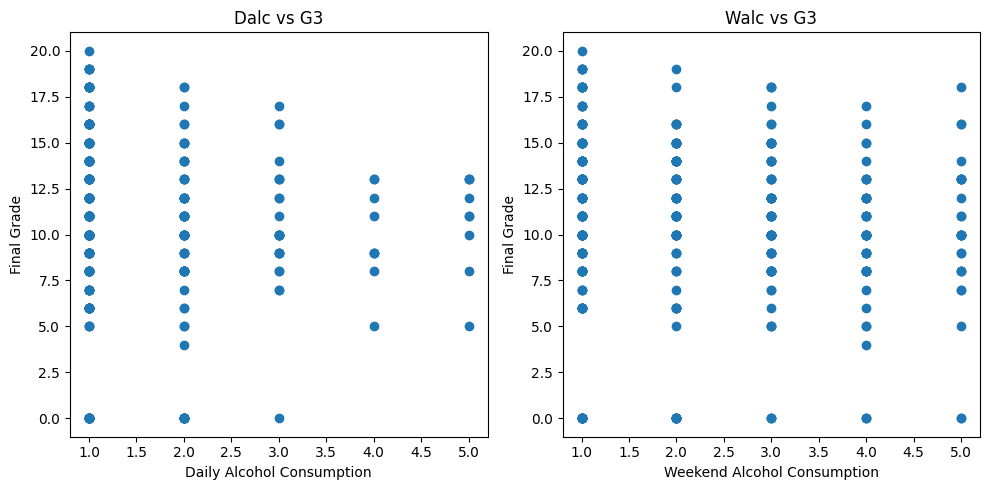

In [19]:
response = agent.invoke("Generate scatter plots to examine the correlation between 'Dalc' (daily alcohol consumption) and 'G3', and between 'Walc' (weekend alcohol consumption) and 'G3'.")

In [20]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.scatter(df['Dalc'], df['G3'])
plt.xlabel('Daily Alcohol Consumption')
plt.ylabel('Final Grade')
plt.title('Dalc vs G3')
plt.subplot(1, 2, 2)
plt.scatter(df['Walc'], df['G3'])
plt.xlabel('Weekend Alcohol Consumption')
plt.ylabel('Final Grade')
plt.title('Walc vs G3')
plt.tight_layout()
plt.show()